In [1]:
# 1) Basic imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay,
)

# NLP / feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Optional: ignore warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

In [3]:
# URL to raw CSV (public gist)
data_url = "https://gist.githubusercontent.com/designernatan/27da044c6dc823f7ac7fe3a01f4513ed/raw/d15b5c7d7a5efb38750b16ec935fc126ec9a6e79/vgsales.csv"

# Load into DataFrame
df = pd.read_csv(data_url)

df.head(5)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 2.1 MB


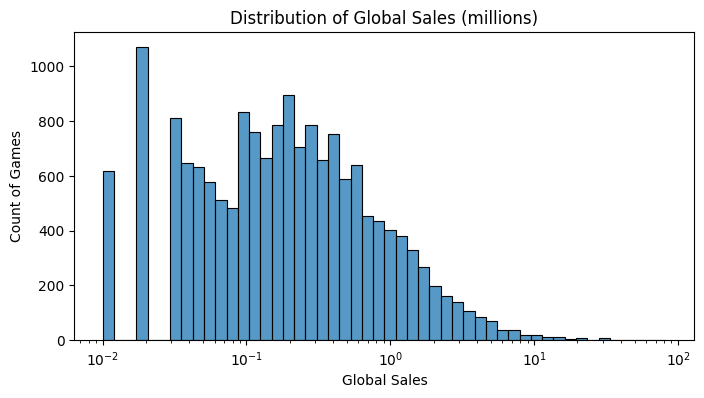

In [5]:
plt.figure(figsize=(8, 4))
sns.histplot(df["Global_Sales"], bins=50, log_scale=(True, False))
plt.title("Distribution of Global Sales (millions)")
plt.xlabel("Global Sales")
plt.ylabel("Count of Games")
plt.show()

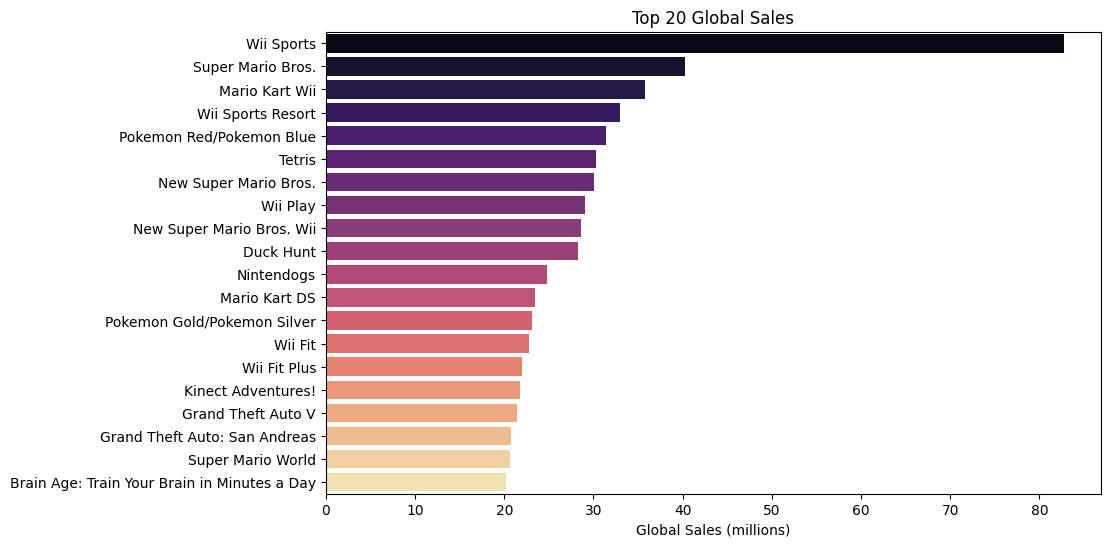

In [6]:
# Top 20 by global sales
top20 = df.sort_values("Global_Sales", ascending=False).head(20)
plt.figure(figsize=(10, 6))
sns.barplot(x="Global_Sales", y="Name", data=top20, palette="magma")
plt.title("Top 20 Global Sales")
plt.xlabel("Global Sales (millions)")
plt.ylabel("")
plt.show()

In [7]:
dead_rising = df[df["Name"].str.contains("Dead Rising", case=False, na=False)]
dead_rising

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
792,794,Dead Rising,X360,2006.0,Action,Capcom,1.16,0.65,0.08,0.20,2.09
1208,1210,Dead Rising 3,XOne,2013.0,Action,Microsoft Game Studios,1.06,0.35,0.01,0.12,1.54
1263,1265,Dead Rising 2,X360,2010.0,Action,Capcom,0.75,0.53,0.09,0.12,1.50
1406,1408,Dead Rising 2,PS3,2010.0,Action,Capcom,0.43,0.57,0.15,0.22,1.38
5558,5560,Dead Rising 2: Off the Record,PS3,2011.0,Action,Capcom,0.11,0.08,0.10,0.03,0.33
6038,6040,Dead Rising: Chop Till You Drop,Wii,2009.0,Action,Capcom,0.15,0.07,0.05,0.02,0.29
6247,6249,Dead Rising 2: Off the Record,X360,2011.0,Action,Capcom,0.17,0.09,0.00,0.02,0.28
9253,9255,Dead Rising 2,PC,2010.0,Action,Capcom,0.10,0.02,0.00,0.01,0.14
12479,12481,Dead Rising 2: Off the Record,PC,2011.0,Action,Capcom,0.04,0.02,0.00,0.01,0.06
15338,15341,Dead Rising,PS4,2016.0,Action,Capcom,0.01,0.00,0.00,0.00,0.02


In [8]:
# Define binary target
threshold = 1.0  # in millions
df["High_Seller"] = (df["Global_Sales"] > threshold).astype(int)

df["High_Seller"].value_counts()

High_Seller
0    14544
1     2054
Name: count, dtype: int64

In [9]:
# Define binary target
threshold = 1.0  # in millions
df["High_Seller"] = (df["Global_Sales"] > threshold).astype(int)

df["High_Seller"].value_counts()

High_Seller
0    14544
1     2054
Name: count, dtype: int64

In [10]:
df = df.dropna(subset=["Year"])  # drop rows without year
df["Year"] = df["Year"].astype(int)

In [11]:
X = df[["Name", "Genre", "Publisher", "Year",
        "NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]]
y = df["High_Seller"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [12]:
# NLP vectorizer for text columns
text_features = ["Name", "Genre", "Publisher"]
numeric_features = ["Year", "NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]

# TF-IDF for text
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=500,   # limit to reduce size; adjust as needed
    ngram_range=(1, 2)  # capture uni- and bigrams
)

# Column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("text", tfidf, text_features),
        ("num", StandardScaler(), numeric_features),
    ],
    remainder='drop'
)

In [17]:
print(X_train.shape)
print(y_train.shape)

(12245, 8)
(12245,)


In [19]:
hasattr(pipeline.named_steps["clf"], "coef_")

False

In [24]:
features = ["Genre","Publisher","Year",
            "NA_Sales","EU_Sales","JP_Sales","Other_Sales"]